# 04 Model Benchmark

This notebook benchmarks five engineered-feature models for PM2.5
estimation under a common, input-controlled evaluation protocol. All
models use the same 55 predictors, date-grouped cross-validation folds,
and date-disjoint hold-out set established in Notebook 3.

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/model_benchmark/`

## Research Question

**RQ3.** How accurately do conventional machine-learning models and a
feature-based deep neural network estimate PM2.5 under a common
multi-source benchmark protocol?

## Workflow Overview

1. Define the common dataset, engineered feature set, and benchmark protocol
2. Evaluate all pre-specified models using date-grouped development cross-validation
3. Evaluate all models once on the common hold-out set
4. Compare cross-validation and hold-out performance
5. Examine prediction diagnostics and computational efficiency
6. Assess sensitivity to the validation strategy


## Setup

In [123]:
import sys
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.config as config
import src.features.evaluation as evaluation
import src.models.benchmark as benchmark
import src.models.plots as benchmark_plots

plt.style.use("default")
mpl.rcParams.update({"font.family": "Times New Roman", "font.size": 11})

RESULTS_DIR = PROJECT_ROOT / "results" / "model_benchmark"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)


Project root: /Users/qingxuan/Desktop/webcam-pm25-toolbox
Results directory: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark


## 1. Dataset and Benchmark Setup

### 1.1 Dataset and Engineered Feature Set

The processed dataset, target, and 55 engineered predictors follow
Notebook 3. A calendar-date identifier keeps observations from the same
date together during data splitting and cross-validation.

In [124]:
# Load data and define the benchmark columns.
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
df = (
    pd.read_csv(DATA_PATH, parse_dates=["time"])
    .sort_values("time")
    .reset_index(drop=True)
)

TARGET = config.TARGET
FEATURES = config.ALL_FEATURES
required_columns = ["time", TARGET, *FEATURES]
missing_columns = [
    column for column in required_columns if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Retain complete cases and create the date-level grouping variable.
benchmark_df = (
    df[required_columns]
    .dropna()
    .reset_index(drop=True)
)
if benchmark_df.empty:
    raise ValueError("No complete samples are available for benchmarking.")
benchmark_df["date_group"] = benchmark_df["time"].dt.normalize()

# Summarise the analysis dataset.
dataset_summary = pd.DataFrame(
    {
        "Item": [
            "Input dataset",
            "Total samples",
            "Benchmark samples",
            "Rows removed due to missing values",
            "Independent dates",
            "Time range",
            "Target variable",
            "Engineered predictors",
        ],
        "Value": [
            DATA_PATH.name,
            f"{len(df):,}",
            f"{len(benchmark_df):,}",
            f"{len(df) - len(benchmark_df):,}",
            benchmark_df["date_group"].nunique(),
            (
                f"{benchmark_df['time'].min():%Y-%m-%d %H:%M} to "
                f"{benchmark_df['time'].max():%Y-%m-%d %H:%M}"
            ),
            TARGET,
            len(FEATURES),
        ],
    }
)

display(dataset_summary)

,Item,Value
0,Input dataset,final_dataset.csv
1,Total samples,"3,180"
2,Benchmark samples,"3,180"
3,Rows removed due to missing values,0
4,Independent dates,186
5,Time range,2025-01-29 15:00 to 2026-07-20 21:00
6,Target variable,PM25
7,Engineered predictors,55


In [125]:
# Use config.py as the single source of truth for feature groups.
feature_groups = config.FEATURE_GROUPS
grouped_features = [
    feature
    for features in feature_groups.values()
    for feature in features
]

# This exact-order check also detects missing, extra, or duplicated features.
if grouped_features != FEATURES:
    raise ValueError("FEATURE_GROUPS and ALL_FEATURES are inconsistent.")

feature_group_summary = pd.DataFrame(
    {
        "Feature Group": [*feature_groups, "Total"],
        "Number of Features": [
            *[len(features) for features in feature_groups.values()],
            len(FEATURES),
        ],
    }
)

display(feature_group_summary)

,Feature Group,Number of Features
0,Image,18
1,ERA5,18
2,ARPA,7
3,Temporal,12
4,Total,55


### 1.2 Benchmark Protocol

The month-aware, date-disjoint development/hold-out split from Notebook
3 is reproduced here. Models are compared using the same five-fold,
unweighted date-grouped CV within the development set, then evaluated
once on the untouched common hold-out set.


In [126]:
# Benchmark configuration
FINAL_TEST_SIZE = 0.20
N_SPLITS = 5
RANDOM_STATE = 42

if not 0 < FINAL_TEST_SIZE < 1:
    raise ValueError("FINAL_TEST_SIZE must be between 0 and 1.")
if N_SPLITS < 2:
    raise ValueError("N_SPLITS must be at least 2.")

protocol_summary = pd.DataFrame(
    [
        ("Development/common hold-out split", "Month-aware date-group split"),
        ("Grouping unit", "Complete calendar date"),
        ("Common hold-out proportion", f"{FINAL_TEST_SIZE * 100:.0f}%"),
        ("Development cross-validation", f"{N_SPLITS}-fold date-grouped"),
        ("Random seed", RANDOM_STATE),
        ("Evaluation metrics", "R², RMSE, MAE"),
    ],
    columns=["Setting", "Value"],
)

display(protocol_summary)


,Setting,Value
0,Development/common hold-out split,Month-aware date-group split
1,Grouping unit,Complete calendar date
2,Common hold-out proportion,20%
3,Development cross-validation,5-fold date-grouped
4,Random seed,42
5,Evaluation metrics,"R², RMSE, MAE"


In [127]:
# Create the month-aware, date-disjoint split used in Notebook 3.
development_df, final_test_df = evaluation.balanced_month_group_split(
    benchmark_df,
    time_column="time",
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
)

if development_df.empty or final_test_df.empty:
    raise ValueError("The development or common hold-out set is empty.")
if set(development_df["date_group"]) & set(final_test_df["date_group"]):
    raise ValueError("Development and hold-out sets contain shared dates.")
if len(development_df) + len(final_test_df) != len(benchmark_df):
    raise ValueError("Split sample counts do not match the benchmark dataset.")

split_summary = pd.DataFrame(
    [
        ("Full benchmark dataset", len(benchmark_df), benchmark_df["date_group"].nunique()),
        ("Development set", len(development_df), development_df["date_group"].nunique()),
        ("Common hold-out", len(final_test_df), final_test_df["date_group"].nunique()),
    ],
    columns=["Subset", "Samples", "Independent dates"],
)
split_summary["Percentage"] = split_summary["Samples"] / len(benchmark_df) * 100
display(split_summary.round({"Percentage": 1}))

# Compare target distributions across the two subsets.
target_distribution_summary = (
    pd.DataFrame(
        {
            "Development set": development_df[TARGET].describe(),
            "Common hold-out": final_test_df[TARGET].describe(),
        }
    )
    .T
    .rename_axis("Subset")
    .reset_index()
    .rename(
        columns={
            "count": "Samples",
            "mean": "Mean",
            "std": "Standard Deviation",
            "min": "Minimum",
            "50%": "Median",
            "max": "Maximum",
        }
    )
    [["Subset", "Samples", "Mean", "Standard Deviation", "Minimum", "Median", "Maximum"]]
)
target_distribution_summary["Samples"] = target_distribution_summary["Samples"].astype(int)
display(target_distribution_summary.round(2))

,Subset,Samples,Independent dates,Percentage
0,Full benchmark dataset,3180,186,100.0
1,Development set,2544,148,80.0
2,Common hold-out,636,38,20.0


,Subset,Samples,Mean,Standard Deviation,Minimum,Median,Maximum
0,Development set,2544,14.92,12.53,0.33,11.05,93.11
1,Common hold-out,636,13.81,9.37,0.78,10.85,46.59


### 1.3 Benchmark Models

The benchmark covers five model families:

- Ridge Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Multilayer Perceptron (MLP)

This provides an input-controlled comparison of linear, tree-based,
ensemble, and neural-network approaches. The pretrained raw-image CNN is
evaluated separately in Notebook 5 because it uses learned image
representations rather than the engineered predictors used here.

In [136]:
# Load model configurations and their display metadata from benchmark.py.
benchmark_models = benchmark.get_benchmark_models(random_state=RANDOM_STATE)
MODEL_ORDER = list(benchmark_models)
model_summary = benchmark.get_model_summary()
model_summary["Input"] = f"{len(FEATURES)} engineered features"

if model_summary["Model"].tolist() != MODEL_ORDER:
    raise ValueError("Model definitions and summary metadata are inconsistent.")

display(model_summary)

,Model,Category,Complexity,Scaling,Input
0,Ridge,Linear,Low,Required,55 engineered features
1,Decision Tree,Tree-based,Low,Not required,55 engineered features
2,Random Forest,Bagging ensemble,Medium,Not required,55 engineered features
3,Gradient Boosting,Boosting ensemble,Medium,Not required,55 engineered features
4,MLP,Neural network,High,Required,55 engineered features


## 2. Development Cross-Validation Benchmark

### 2.1 Engineered-Feature Model Evaluation

All models are evaluated on identical unweighted, date-grouped folds
within the development set. The common hold-out remains untouched.


In [19]:
# Evaluate the five engineered-feature models using
# unweighted date-grouped development cross-validation

traditional_results = []
traditional_fold_results = []

for model_name, model in benchmark_models.items():

    (
        summary,
        fold_results,
        _,
        _,
    ) = evaluation.evaluate_feature_set(
        model=model,
        model_name=model_name,
        feature_set_name="All Features",
        feature_list=FEATURES,
        development_df=development_df,

        # Required by the interface but not accessed
        # because evaluate_test=False.
        test_df=final_test_df,

        target=TARGET,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,

        # Keep complete dates in the same fold.
        group_column="date_group",

        # No inverse-frequency training or metric weights.
        balance_column=None,

       # The common hold-out set remains unused.
        evaluate_test=False,
    )

    traditional_results.append(
        summary
    )

    traditional_fold_results.append(
        fold_results.assign(
            Model=model_name
        )
    )

traditional_results = pd.concat(
    traditional_results,
    ignore_index=True,
)

traditional_fold_results = pd.concat(
    traditional_fold_results,
    ignore_index=True,
)

execution_summary = pd.DataFrame(
    {
        "Item": [
            "Benchmark status",
            "Models evaluated",
            "Development samples",
            "Independent development dates",
            "Engineered predictors",
            "Cross-validation",
            "Training and metric weights",
            "Common hold-out used",
        ],
        "Value": [
            "Completed",
            len(traditional_results),
            f"{len(development_df):,}",
            development_df["date_group"].nunique(),
            len(FEATURES),
            f"{N_SPLITS}-fold date-grouped CV",
            "None",
            "No",
        ],
    }
)

display(execution_summary)


,Item,Value
0,Benchmark status,Completed
1,Models evaluated,5
2,Development samples,"2,544"
3,Independent development dates,148
4,Engineered predictors,55
5,Cross-validation,5-fold date-grouped CV
6,Training and metric weights,None
7,Locked final test used,No


### 2.2 Engineered-Feature Model Performance

Mean R², RMSE, and MAE summarise predictive performance across the five
folds; their standard deviations describe fold-to-fold stability. The
CV-only figure is supplementary, while Section 3.2 presents the main
comparison with hold-out performance.


In [20]:
# Summarise development cross-validation performance

cv_columns = [
    "Model",
    "Variables",
    "CV MAE",
    "CV MAE Std",
    "CV RMSE",
    "CV RMSE Std",
    "CV R2",
    "CV R2 Std",
]

traditional_cv_summary = (
    traditional_results[cv_columns]
    .sort_values(
        by=[
            "CV R2",
            "CV RMSE",
            "CV MAE",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

traditional_cv_summary.insert(
    0,
    "Rank",
    range(
        1,
        len(traditional_cv_summary) + 1,
    ),
)

traditional_cv_display = (
    traditional_cv_summary.copy()
)

metric_columns = [
    "CV MAE",
    "CV MAE Std",
    "CV RMSE",
    "CV RMSE Std",
    "CV R2",
    "CV R2 Std",
]

traditional_cv_display[
    metric_columns
] = (
    traditional_cv_display[
        metric_columns
    ]
    .round(3)
)

display(traditional_cv_display)

,Rank,Model,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,1,Gradient Boosting,55,4.453,0.224,6.185,0.235,0.749,0.035
1,2,Random Forest,55,4.760,0.279,6.627,0.352,0.712,0.035
2,3,MLP,55,5.023,0.448,6.867,0.658,0.686,0.085
3,4,Ridge,55,5.262,0.361,6.987,0.403,0.678,0.058
4,5,Decision Tree,55,5.517,0.494,7.874,0.871,0.597,0.050


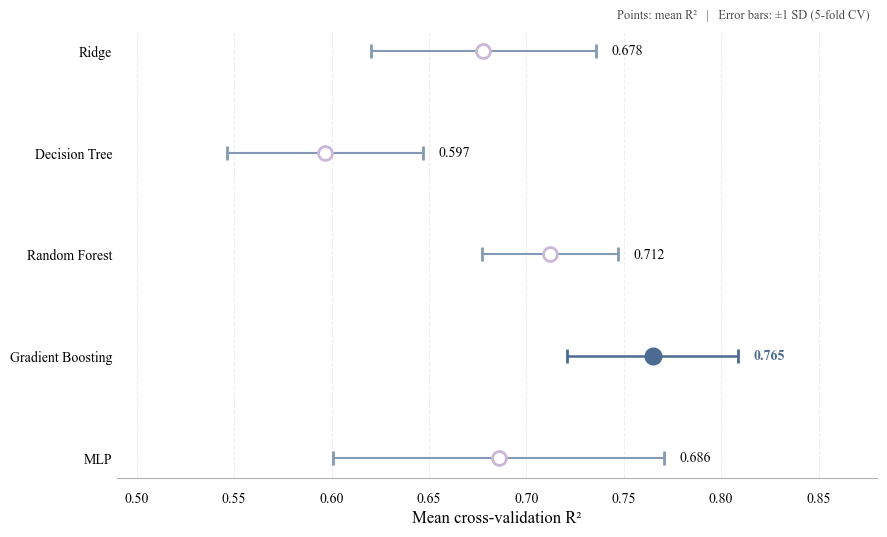

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/engineered_feature_model_cv_r2.png


In [103]:
# Development CV R² of the engineered-feature models

fig_1, ax_1 = (
    benchmark_plots.plot_cross_validation_benchmark(
        benchmark_results=traditional_results,
        output_path=(
            RESULTS_DIR
            / "engineered_feature_model_cv_r2.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(9, 5.5),
        point_color="#CBB8D9",
        error_color="#8599B4",
        marker_size=10,
        dpi=300,
    )
)

plt.show()

In [22]:
# Export development-CV results for Notebook 5

TRADITIONAL_RESULTS_PATH = (
    RESULTS_DIR
    / "traditional_model_cv_results.csv"
)

traditional_results.to_csv(
    TRADITIONAL_RESULTS_PATH,
    index=False,
)

print(
    "Traditional-model CV results saved to:",
    TRADITIONAL_RESULTS_PATH,
)


Traditional-model CV results saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/traditional_model_cv_results.csv


## 3. Common Hold-out Evaluation

All five predefined benchmark methods are fitted on the complete development set and evaluated once on the same common hold-out set. The model definitions and hyperparameters remain fixed. Hold-out results are used for comparative accuracy reporting and are not used for subsequent tuning.

In [23]:
# Fit every pre-specified benchmark model on the complete
# development set and evaluate it on the common hold-out set

fitted_models = {}
predictions = {}
holdout_records = []

for model_name, model in benchmark_models.items():
    fitted_model = clone(model)

    train_start = time.perf_counter()
    fitted_model.fit(
        development_df[FEATURES],
        development_df[TARGET],
    )
    train_time = (
        time.perf_counter()
        - train_start
    )

    predict_start = time.perf_counter()
    test_prediction = fitted_model.predict(
        final_test_df[FEATURES]
    )
    predict_time = (
        time.perf_counter()
        - predict_start
    )

    test_metrics = (
        evaluation.evaluate_regression(
            final_test_df[TARGET],
            test_prediction,
        )
    )

    fitted_models[model_name] = (
        fitted_model
    )

    predictions[model_name] = pd.DataFrame(
        {
            "Observed":
                final_test_df[TARGET]
                .to_numpy(),
            "Predicted":
                test_prediction,
            "Residual": (
                final_test_df[TARGET]
                .to_numpy()
                - test_prediction
            ),
        }
    )

    holdout_records.append(
        {
            "Model": model_name,
            "Test MAE":
                test_metrics["MAE"],
            "Test RMSE":
                test_metrics["RMSE"],
            "Test R2":
                test_metrics["R2"],
            "Train Time (s)":
                train_time,
            "Predict Time (s)":
                predict_time,
        }
    )

holdout_results = pd.DataFrame(
    holdout_records
)

benchmark_results = (
    traditional_results
    .merge(
        holdout_results,
        on="Model",
        how="inner",
        validate="one_to_one",
    )
)

benchmark_results.to_csv(
    RESULTS_DIR
    / "traditional_model_benchmark_results.csv",
    index=False,
)

print(
    "All predefined models evaluated "
    "on the common hold-out set."
)

All predefined models evaluated on the common hold-out set.


### 3.1 Hold-out Accuracy Ranking

Methods are ordered descriptively by common hold-out R². The ranking summarises comparative accuracy; it is not used to revise model configurations.

In [24]:
test_summary = (
    benchmark_results[
        [
            "Model",
            "Test MAE",
            "Test RMSE",
            "Test R2",
        ]
    ]
    .sort_values(
        [
            "Test R2",
            "Test RMSE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

test_summary.insert(
    0,
    "Rank",
    range(1, len(test_summary) + 1),
)

display(
    test_summary.round(3)
)

,Rank,Model,Test MAE,Test RMSE,Test R2
0,1,Gradient Boosting,4.323,5.879,0.606
1,2,Random Forest,4.910,6.510,0.516
2,3,Ridge,4.929,6.727,0.484
3,4,MLP,5.002,6.840,0.466
4,5,Decision Tree,5.904,8.211,0.231


### 3.2 Unified Cross-Validation and Hold-out Summary

Grouped bars compare mean date-grouped CV R² with common hold-out R².
Error bars show ±1 CV standard deviation, and ΔR² labels report the
descriptive CV-minus-hold-out difference. These gaps should be interpreted
alongside the different PM2.5 distributions in the two subsets.

In [26]:
comparison_summary = (
    benchmark_results[
        [
            "Model",
            "CV R2",
            "CV R2 Std",
            "Test R2",
            "CV RMSE",
            "Test RMSE",
            "CV MAE",
            "Test MAE",
        ]
    ]
    .copy()
)

comparison_summary[
    "R2 Gap"
] = (
    comparison_summary["CV R2"]
    - comparison_summary["Test R2"]
)

comparison_summary = (
    comparison_summary
    .sort_values(
        "Test R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison_summary.round(3)
)

,Model,CV R2,CV R2 Std,Test R2,CV RMSE,Test RMSE,CV MAE,Test MAE,R2 Gap
0,Gradient Boosting,0.749,0.035,0.606,6.185,5.879,4.453,4.323,0.143
1,Random Forest,0.712,0.035,0.516,6.627,6.510,4.760,4.910,0.196
2,Ridge,0.678,0.058,0.484,6.987,6.727,5.262,4.929,0.194
3,MLP,0.686,0.085,0.466,6.867,6.840,5.023,5.002,0.220
4,Decision Tree,0.597,0.050,0.231,7.874,8.211,5.517,5.904,0.366


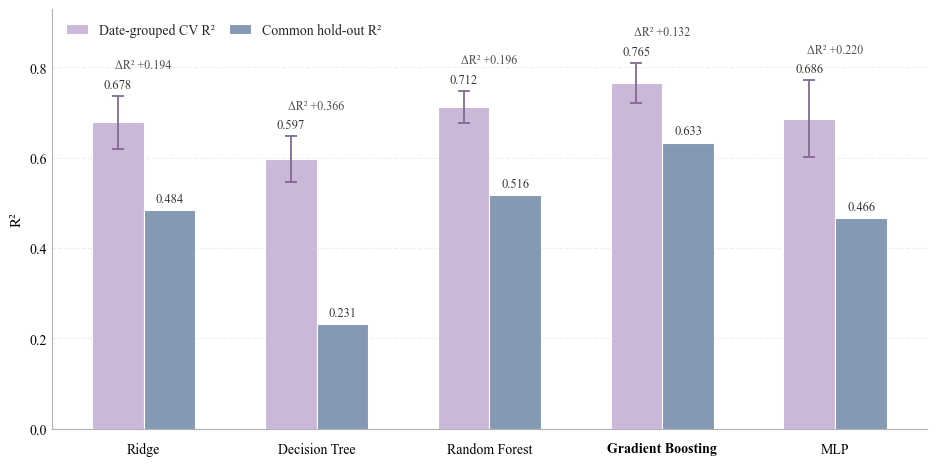

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/cv_vs_common_holdout.png


In [112]:
fig_3, ax_3 = (
    benchmark_plots
    .plot_cv_test_comparison(
        benchmark_results=(
            benchmark_results
        ),
        output_path=(
            RESULTS_DIR
            / "cv_vs_common_holdout.png"
        ),
        model_order=MODEL_ORDER,
        figure_size=(9.5, 4.8),
        cv_color="#CBB8D9",
        test_color="#8599B4",
        bar_width=0.30,
        dpi=300,
    )
)

plt.show()

## 4. Prediction Diagnostics

Diagnostics focus on the model with the highest common hold-out R². The
first panel compares observed and predicted PM2.5 using density shading,
a 1:1 reference, and a calibration line; the second shows prediction
errors and quantile-binned mean error across the observed range.

### 4.1 Selected-Model Hold-out Diagnostics


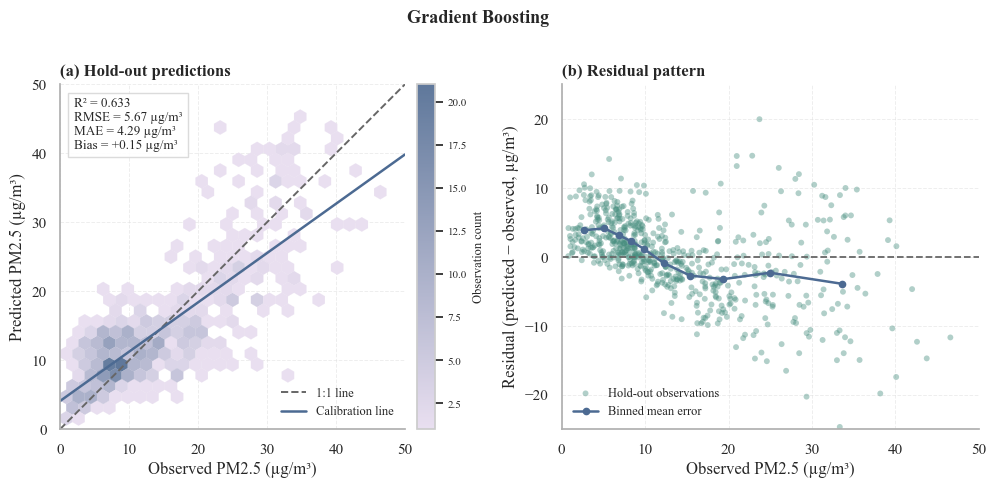

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/best_model_holdout_diagnostics.png


In [114]:
BEST_MODEL_NAME = (
    benchmark_results
    .sort_values(["Test R2", "Test RMSE"], ascending=[False, True])
    .iloc[0]["Model"]
)

fig_4, axes_4 = (
    benchmark_plots
    .plot_best_model_holdout_diagnostics(
        predictions=predictions,
        benchmark_results=(
            benchmark_results
        ),
        model_name=BEST_MODEL_NAME,
        output_path=(
            RESULTS_DIR
            / "best_model_holdout_diagnostics.png"
        ),
        figure_size=(10.5, 4.8),
        density_low="#E9DFF0",
        density_high="#5F789B",
        residual_color="#478E7F",
        trend_color="#4C6A92",
        dpi=300,
    )
)

plt.show()

### 4.2 Cross-Model Calibration Summary

To complement the detailed diagnostic figure for the selected model, calibration is summarised numerically for all five benchmark methods on the common hold-out set. Mean bias is defined as predicted minus observed PM2.5. A well-calibrated model has a slope close to 1, an intercept close to 0, and a mean bias close to 0.

In [116]:
calibration_records = []

for model_name in MODEL_ORDER:
    prediction_df = predictions[model_name]
    observed = pd.to_numeric(
        prediction_df["Observed"], errors="coerce"
    )
    predicted = pd.to_numeric(
        prediction_df["Predicted"], errors="coerce"
    )
    valid = observed.notna() & predicted.notna()
    observed = observed[valid].to_numpy()
    predicted = predicted[valid].to_numpy()

    calibration_slope, calibration_intercept = np.polyfit(
        observed, predicted, deg=1
    )
    calibration_records.append(
        {
            "Model": model_name,
            "Hold-out Samples": len(observed),
            "Mean Bias": np.mean(predicted - observed),
            "Calibration Slope": calibration_slope,
            "Calibration Intercept": calibration_intercept,
        }
    )

calibration_summary = pd.DataFrame(calibration_records)
display(calibration_summary.round(3))

calibration_summary.to_csv(
    RESULTS_DIR / "all_model_calibration_summary.csv",
    index=False,
)

,Model,Hold-out Samples,Mean Bias,Calibration Slope,Calibration Intercept
0,Ridge,636,0.386,0.895,1.839
1,Decision Tree,636,0.125,0.571,6.041
2,Random Forest,636,-0.195,0.598,5.350
3,Gradient Boosting,636,0.147,0.715,4.083
4,MLP,636,1.096,0.908,2.366


## 5. Computational Efficiency

Training and prediction times are reported as supplementary practical
characteristics. They are hardware-dependent, are interpreted separately
from predictive accuracy, and are intended for appendix-level reporting.

,Model,Train Time (s),Predict Time (s)
0,Ridge,0.0349,0.0038
1,Decision Tree,0.2249,0.0093
2,Random Forest,4.8811,0.0443
3,Gradient Boosting,2.8800,0.0059
4,MLP,44.8024,0.0260


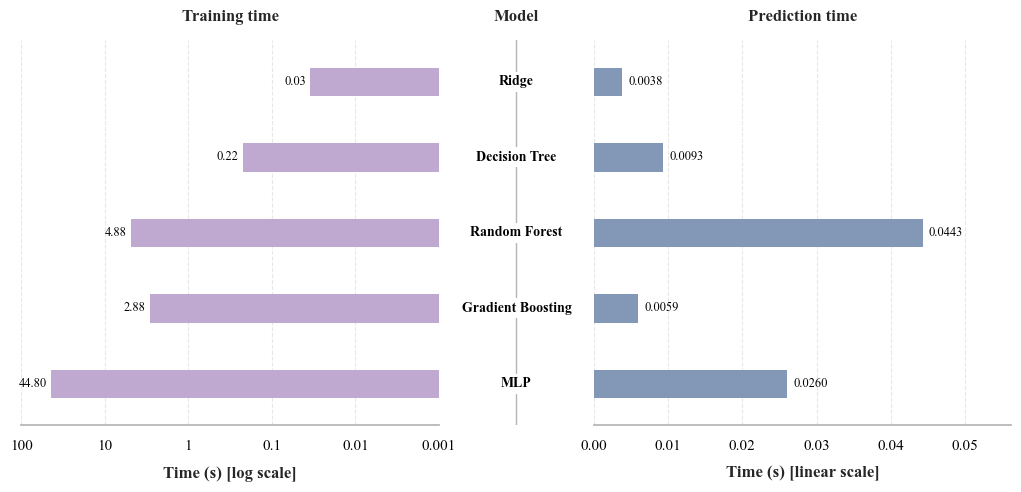

In [107]:
efficiency_summary = (
    benchmark_results[
        [
            "Model",
            "Train Time (s)",
            "Predict Time (s)",
        ]
    ]
    .copy()
)

display(
    efficiency_summary.round(4)
)

fig_5, axes_5 = (
    benchmark_plots
    .plot_computational_efficiency(
        benchmark_results=(
            benchmark_results
        ),
        output_path=(
            RESULTS_DIR
            / "computational_efficiency.png"
        ),
        model_order=MODEL_ORDER,
        figure_size=(11, 5.5),
        train_color="#BFA9D1",
        predict_color="#8397B7",
        separator_color="#E0E0E0",
        center_line_color="#B5B5B5",
        bar_height=0.38,
        dpi=300,
    )
)

plt.show()

## 6. Validation-Strategy Sensitivity Analysis

This supplementary analysis compares the primary date-isolated protocol
with row-wise random splitting for development CV and 80/20 hold-out
evaluation. All other settings remain fixed. Because row-wise splitting
can place observations from the same date on both sides of a validation
boundary, its results quantify validation-design sensitivity and are not
used for model selection or tuning.

In [87]:
# Evaluate sensitivity to row-wise random cross-validation

random_cv_results = []

for model_name, model in benchmark_models.items():

    (
        summary,
        _,
        _,
        _,
    ) = evaluation.evaluate_feature_set(
        model=model,
        model_name=model_name,
        feature_set_name="All Features",
        feature_list=FEATURES,
        development_df=development_df,

        # Not accessed because evaluate_test=False.
        test_df=final_test_df,

        target=TARGET,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,

        # Row-wise random folds; dates are not grouped.
        group_column=None,

        # Use unweighted fitting and evaluation.
        balance_column=None,

        # The common hold-out set remains unused.
        evaluate_test=False,
    )

    random_cv_results.append(summary)

random_cv_results = pd.concat(
    random_cv_results,
    ignore_index=True,
)

# Create the parallel row-wise 80/20 hold-out used only for
# validation-strategy sensitivity analysis.
rowwise_development_df, rowwise_test_df = evaluation.random_split(
    benchmark_df,
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
)

rowwise_holdout_records = []
for model_name, model in benchmark_models.items():
    metrics, _ = evaluation.evaluate_holdout(
        model=model,
        feature_list=FEATURES,
        development_df=rowwise_development_df,
        test_df=rowwise_test_df,
        target=TARGET,
        balance_column=None,
    )
    rowwise_holdout_records.append(
        {"Model": model_name, "Row-Wise Hold-out R2": metrics["R2"]}
    )

rowwise_holdout_results = pd.DataFrame(rowwise_holdout_records)

In [90]:
validation_strategy_summary = (
    traditional_results[
        [
            "Model",
            "CV R2",
            "CV RMSE",
            "CV MAE",
        ]
    ]
    .rename(
        columns={
            "CV R2": "Date-Grouped CV R2",
            "CV RMSE": "Date-Grouped CV RMSE",
            "CV MAE": "Date-Grouped CV MAE",
        }
    )
    .merge(
        random_cv_results[
            [
                "Model",
                "CV R2",
                "CV RMSE",
                "CV MAE",
            ]
        ]
        .rename(
            columns={
                "CV R2": "Row-Wise CV R2",
                "CV RMSE": "Row-Wise CV RMSE",
                "CV MAE": "Row-Wise CV MAE",
            }
        ),
        on="Model",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        benchmark_results[["Model", "Test R2"]]
        .rename(
            columns={"Test R2": "Common Hold-out R2"}
        ),
        on="Model",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        rowwise_holdout_results,
        on="Model",
        how="inner",
        validate="one_to_one",
    )
)

validation_strategy_summary[
    "CV R2 Optimism Gap"
] = (
    validation_strategy_summary["Row-Wise CV R2"]
    - validation_strategy_summary["Date-Grouped CV R2"]
)

validation_strategy_summary["Hold-out R2 Difference"] = (
    validation_strategy_summary["Row-Wise Hold-out R2"]
    - validation_strategy_summary["Common Hold-out R2"]
)

validation_strategy_summary = (
    validation_strategy_summary
    .sort_values(
        "Date-Grouped CV R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

validation_strategy_summary = validation_strategy_summary[
    [
        "Model",
        "Date-Grouped CV R2",
        "Date-Grouped CV RMSE",
        "Date-Grouped CV MAE",
        "Row-Wise CV R2",
        "Row-Wise CV RMSE",
        "Row-Wise CV MAE",
        "CV R2 Optimism Gap",
        "Common Hold-out R2",
        "Row-Wise Hold-out R2",
        "Hold-out R2 Difference",
    ]
]

display(
    validation_strategy_summary.round(3)
)

,Model,Date-Grouped CV R2,Date-Grouped CV RMSE,Date-Grouped CV MAE,Row-Wise CV R2,Row-Wise CV RMSE,Row-Wise CV MAE,CV R2 Optimism Gap,Common Hold-out R2,Row-Wise Hold-out R2,Hold-out R2 Difference
0,Gradient Boosting,0.765,5.964,4.339,0.869,4.532,3.322,0.104,0.633,0.878,0.245
1,Random Forest,0.712,6.627,4.760,0.824,5.246,3.838,0.112,0.516,0.853,0.337
2,MLP,0.686,6.867,5.023,0.840,4.996,3.707,0.154,0.466,0.869,0.403
3,Ridge,0.678,6.987,5.262,0.735,6.445,4.856,0.057,0.484,0.747,0.263
4,Decision Tree,0.597,7.874,5.517,0.765,6.061,4.289,0.169,0.231,0.771,0.541
